In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

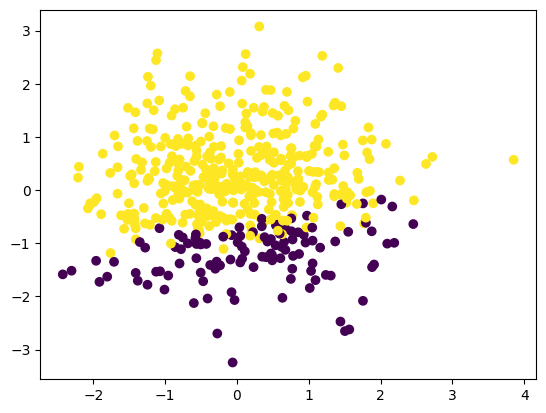

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5104284745369558, Val loss:0.5096830037085237
100. Training loss: 0.475572188153663, Val loss:0.4776817269491726
150. Training loss: 0.44662948900734395, Val loss:0.4511228642557118
200. Training loss: 0.4224465519218822, Val loss:0.42893988060421745
250. Training loss: 0.4020880450778015, Val loss:0.41026719448247295
300. Training loss: 0.3848069814383682, Val loss:0.3944142692703644
350. Training loss: 0.37001160745178474, Val loss:0.3808353870901958
400. Training loss: 0.35723469403555763, Val loss:0.36910084303078516
450. Training loss: 0.3461073125618179, Val loss:0.3588721657815527
500. Training loss: 0.3363374478661988, Val loss:0.34988196189733695
550. Training loss: 0.32769302298007397, Val loss:0.34191801918859355
600. Training loss: 0.3199886403501635, Val loss:0.33481097487299777
650. Training loss: 0.3130753186253522, Val loss:0.32842482578799465
700. Training loss: 0.30683258165267435, Val loss:0.3226496464272412
7

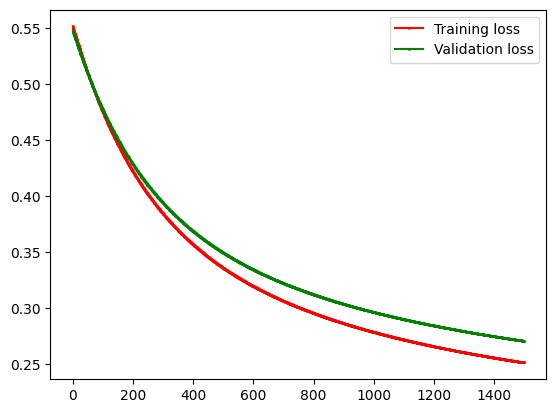

Logistic Regression Evaluation
Accuracy  : 0.9231
Precision : 0.9360
Recall    : 0.9244
F1-score  : 0.9302


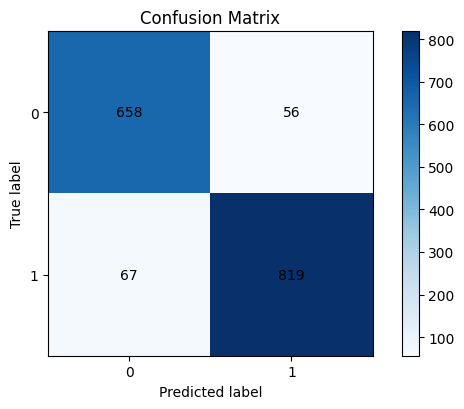

{'Accuracy': 0.923125,
 'Precision': 0.936,
 'Recall': 0.9243792325056434,
 'F1-score': 0.9301533219761499}

In [50]:
# for Q2

# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1


# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =1500,val_ratio=0.2)

# Get the Prediction
y_val_pred = model.predict(X_val)

# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

In [4]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


20. Training loss: 0.9881638457810773, Val loss:0.9645922922843523
40. Training loss: 0.9363184152246646, Val loss:0.9145933994581312
60. Training loss: 0.8881255625797497, Val loss:0.8681824340076577
80. Training loss: 0.8435013650703489, Val loss:0.8252770470945283
100. Training loss: 0.8023254524923707, Val loss:0.7857578532165119
120. Training loss: 0.76444573392194, Val loss:0.7494732570750171
140. Training loss: 0.7296845906457493, Val loss:0.7162457692441115
160. Training loss: 0.6978459139764438, Val loss:0.6858791790119394
180. Training loss: 0.6687223195489947, Val loss:0.6581659125603253
200. Training loss: 0.6421019406042985, Val loss:0.6328939736163959
220. Training loss: 0.6177743566104512, Val loss:0.6098530110981566
240. Training loss: 0.5955353995655434, Val loss:0.5888392400909019
260. Training loss: 0.5751907540224198, Val loss:0.569659118137967
280. Training loss: 0.5565584019616943, Val loss:0.5521318211243628
300. Training loss: 0.5394700517290799, Val loss:0.5360

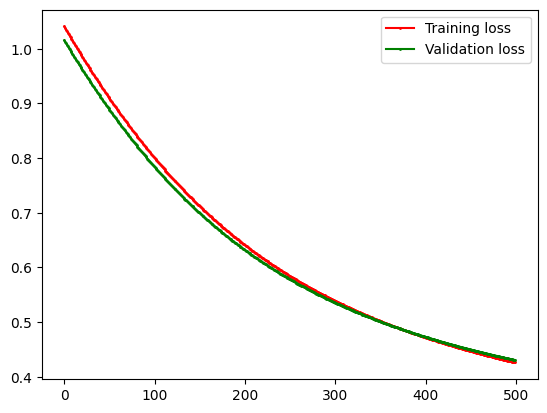

In [5]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [6]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


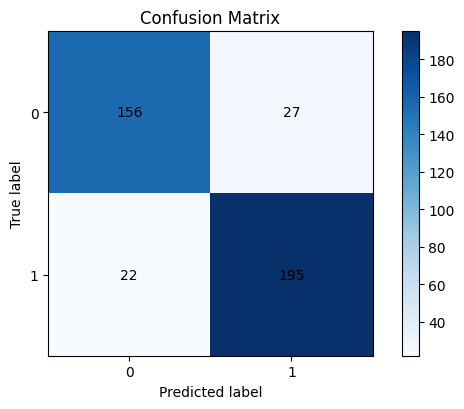

{'Accuracy': 0.8775,
 'Precision': 0.8783783783783784,
 'Recall': 0.8986175115207373,
 'F1-score': 0.8883826879271071}

In [8]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

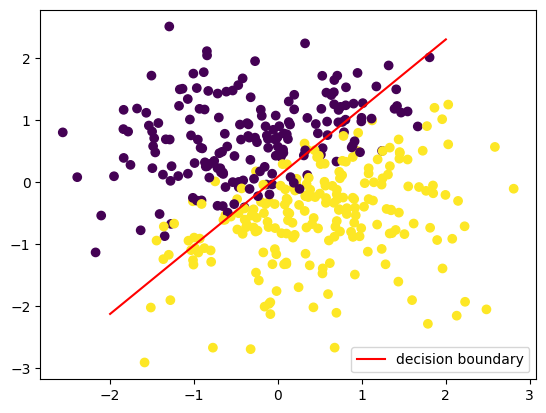

In [9]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()